#AI Customer Churn Intelligence System

Problem: Companies usually know which customers are at risk of leaving, but not why — and even if they know why, they don't always know what to do about it. This project closes that loop.

#What it does:

Trains a Random Forest model to predict churn probability per customer
Uses SHAP to break down exactly which factors are driving each individual customer's risk (not just global feature importance)
Feeds those factors to AI, which writes a specific, actionable retention recommendation for the account team

#Sample output:

Customer ID: 0604-THJFP
Churn Probability: 2%
Main Reasons: [('Contract', -0.087), ('tenure', -0.054), ('TechSupport', -0.032)]

#AI Recommendation:
Recommend proactively reaching out with a personalized contract-renewal
incentive (small discount or bonus months), bundled with a complimentary
Tech Support upgrade — this reinforces the existing low-churn signals
before any renewal decision is made.

Model performance:

Metric	Score
AUC	0.83
Accuracy	0.79
Precision (churn class)	0.65
Recall (churn class)	0.49
Dataset: Telco Customer Churn (IBM sample dataset, loaded directly from a public URL — no download needed)
Tech: Python, scikit-learn (Random Forest), SHAP, Cerebras/Groq API

In [ ]:
# AI Customer Churn Intelligence System
# what this does: predicts which customers will leave (churn), explains why using
# SHAP, and asks AI to suggest what the team should do about it

# free AI setup - using cerebras first, groq as backup, ollama as last option
# get free api key from https://cloud.cerebras.ai and https://console.groq.com
# !pip install -q openai shap

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from getpass import getpass
import os
import requests
from openai import OpenAI
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings("ignore")

# asking for api keys
if not os.environ.get("CEREBRAS_API_KEY"):
    os.environ["CEREBRAS_API_KEY"] = getpass("Enter your Cerebras API key: ")
if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

cerebras_client = OpenAI(api_key=os.environ["CEREBRAS_API_KEY"], base_url="https://api.cerebras.ai/v1")
groq_client = OpenAI(api_key=os.environ["GROQ_API_KEY"], base_url="https://api.groq.com/openai/v1")
OLLAMA_URL = "http://localhost:11434/api/generate"

def call_llm(prompt):
    try:
        response = cerebras_client.chat.completions.create(
            model="gpt-oss-120b",
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print("cerebras failed:", e)

    try:
        response = groq_client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print("groq failed:", e)

    try:
        resp = requests.post(OLLAMA_URL, json={"model": "llama3", "prompt": prompt, "stream": False})
        resp.raise_for_status()
        return resp.json()["response"].strip()
    except Exception as e:
        print("ollama failed too:", e)
        return "AI call failed, all 3 options did not work"







In [ ]:

# step 1 - load data (using the public telco churn dataset from github, no download needed)
telco_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(telco_url)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
print("loaded", len(df), "rows")




loaded 7032 rows


In [ ]:
# step 2 - convert text columns to numbers (models only understand numbers)
cat_cols = df.select_dtypes(include="object").columns.drop("customerID", errors="ignore")
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [ ]:
# step 3 - split data into train and test
features = [c for c in df.columns if c not in ["customerID", "Churn"]]
X = df[features]
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)




In [ ]:

# step 4 - train a random forest model to predict churn
model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
predictions_proba = model.predict_proba(X_test)[:, 1]

print("AUC score:", roc_auc_score(y_test, predictions_proba))
print(classification_report(y_test, model.predict(X_test)))



AUC score: 0.8337806917187363
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
# step 5 - use SHAP to figure out WHY each customer might churn
explainer = shap.TreeExplainer(model)
raw_shap = explainer.shap_values(X_test)

# newer shap versions give a 3d array instead of a list, handling both cases here
if isinstance(raw_shap, list):
    shap_values = raw_shap[1]
elif raw_shap.ndim == 3:
    shap_values = raw_shap[:, :, 1]
else:
    shap_values = raw_shap

def top_reasons(customer_index, n=3):
    row = shap_values[customer_index]
    top_n = np.argsort(-np.abs(row))[:n]
    return [(X_test.columns[i], round(row[i], 3)) for i in top_n]



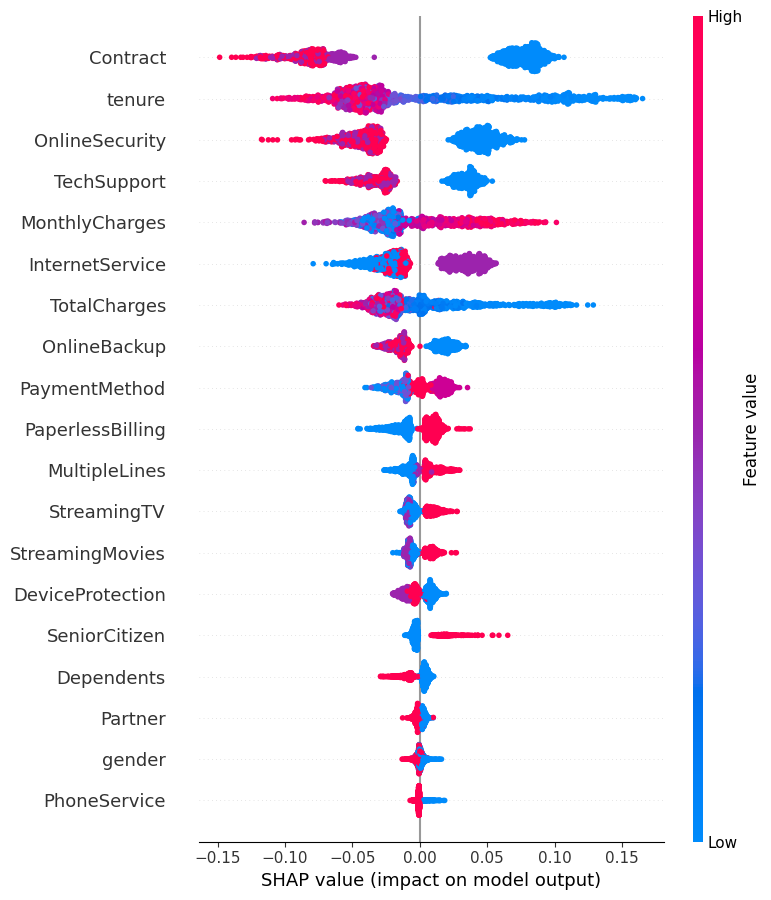

In [ ]:

# step 6 - make a chart showing which features matter most overall
shap.summary_plot(shap_values, X_test,)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.close()




In [ ]:
# step 7 - ask ai what the retention team should do for this customer
def ai_recommendation(customer_id, churn_prob, reasons):
    prompt = f"""Customer {customer_id} has a {churn_prob:.0%} chance of leaving (churning).
The main reasons (from SHAP analysis) are: {reasons}
In 2 sentences, suggest one specific thing the retention team could do to keep this customer."""
    return call_llm(prompt)


In [ ]:
# step 8 - put together a full report for one customer
def customer_report(index):
    customer_id = df.loc[X_test.index[index], "customerID"]
    prob = predictions_proba[index]
    reasons = top_reasons(index)
    recommendation = ai_recommendation(customer_id, prob, reasons)

    print("Customer ID:", customer_id)
    print("Churn Probability:", f"{prob:.0%}")
    print("Main Reasons:", reasons)
    print("AI Recommendation:", recommendation)


if __name__ == "__main__":
    customer_report(0)

cerebras failed: Error code: 402 - {'message': 'Payment required to access this resource. Visit your billing tab.', 'type': 'payment_required_error', 'param': 'quota', 'code': 'payment_required'}
Customer ID: 0604-THJFP
Churn Probability: 2%
Main Reasons: [('Contract', np.float64(-0.087)), ('tenure', np.float64(-0.054)), ('TechSupport', np.float64(-0.032))]
AI Recommendation: Offer the customer a short‑term contract extension with a modest discount or added benefits (e.g., free premium tech‑support for the next 3 months) to offset the churn risk associated with their current contract length and limited support usage. This targeted incentive directly addresses the contract‑related and tech‑support factors while rewarding their tenure, encouraging them to stay longer.
